In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/MSc_Project_Upgrade")
sys.path.append(str(PROJECT_ROOT))

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
import time

from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

from utils.dataset   import JetDataset, event_wise_split, get_indices_from_events
from utils.modelarch import JetViT

from tqdm import tqdm

# ── paths ─────────────────────────────────────────────────────────
DATA_PATH   = PROJECT_ROOT / "datasets/cnn_vit/jet_images_125GeV_train.npz"
RESULT_PATH = PROJECT_ROOT / "results_analysis/vit/ViT_model1_125GeV"
RESULT_PATH.mkdir(parents=True, exist_ok=True)

# ── reproducibility ───────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def get_device():
    if torch.cuda.is_available():    return torch.device("cuda")
    elif torch.backends.mps.is_available(): return torch.device("mps")
    else:                            return torch.device("cpu")

# ── config ────────────────────────────────────────────────────────
config = {
    "batch_size" : 256,
    "lr"         : 3e-4,
    "epochs"     : 75,
    "seed"       : 42,
    "clip_norm"  : 1.0,
    "device"     : get_device(),
    # ViT architecture
    "patch_size" : 4,
    "emb_dim"    : 128,
    "depth"      : 4,
    "num_heads"  : 4,
    "mlp_dim"    : 256,
    "dropout"    : 0.1,
}

set_seed(config["seed"])
print(f"Device : {config['device']}")

Device : cuda


In [3]:
# ── load data & split ─────────────────────────────────────────────
data      = np.load(DATA_PATH)
event_ids = data["event_id"]
labels    = data["labels"]
sample_id = data["sample_id"]

train_events, val_events = event_wise_split(event_ids, val_fraction=0.2, seed=42)
train_idx = get_indices_from_events(event_ids, train_events)
val_idx   = get_indices_from_events(event_ids, val_events)

print(f"Train jets : {len(train_idx)} | Val jets : {len(val_idx)}")

# ── dataloaders ───────────────────────────────────────────────────
train_dataset = JetDataset(DATA_PATH, indices=train_idx)
val_dataset   = JetDataset(DATA_PATH, indices=val_idx)

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=config["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)

Train jets : 353558 | Val jets : 88332


In [4]:
# ── class weights ─────────────────────────────────────────────────
train_labels = labels[train_idx]
n_signal     = int(np.sum(train_labels == 1))
n_background = int(np.sum(train_labels == 0))
pos_weight   = n_background / n_signal
print(f"Signal : {n_signal} | Background : {n_background} | pos_weight : {pos_weight:.4f}")
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(config["device"])

# ── early stopping ────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_auc   = -float("inf")
        self.counter    = 0
        self.best_state = None

    def step(self, val_auc, model):
        if val_auc > self.best_auc + self.min_delta:
            self.best_auc   = val_auc
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

# ── model ─────────────────────────────────────────────────────────
model = JetViT(
    input_shape = (3, 32, 32),
    patch_size  = config["patch_size"],
    emb_dim     = config["emb_dim"],
    depth       = config["depth"],
    num_heads   = config["num_heads"],
    mlp_dim     = config["mlp_dim"],
    dropout     = config["dropout"]
).to(config["device"])

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model : {model.__class__.__name__} | Params : {n_params:,}")
print(f"Patches : {(32 // config['patch_size'])**2} | "
      f"Tokens (with CLS) : {(32 // config['patch_size'])**2 + 1}")

# ── loss / optimiser / scheduler ─────────────────────────────────
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=config["lr"], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-6)
early_stopping = EarlyStopping(patience=10, min_delta=1e-4)

Signal : 142500 | Background : 211058 | pos_weight : 1.4811
Model : JetViT | Params : 545,281
Patches : 64 | Tokens (with CLS) : 65


In [5]:
# ── train / validate functions ────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device, clip_norm):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc="  Train", leave=False):
        images = batch["image"].to(device)
        lbls   = batch["label"].to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_labels, all_scores = [], []
    all_event, all_pt, all_sid = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="  Val  ", leave=False):
            images = batch["image"].to(device)
            lbls   = batch["label"].to(device)
            logits = model(images)
            loss   = criterion(logits, lbls)
            probs  = torch.sigmoid(logits)
            total_loss += loss.item()
            all_labels.append(lbls.cpu().numpy())
            all_scores.append(probs.cpu().numpy())
            all_event.append(batch["event_id"].numpy())
            all_pt.append(batch["jet_pt"].numpy())
            all_sid.append(batch["sample_id"].numpy())
    y_true  = np.concatenate(all_labels)
    y_score = np.concatenate(all_scores)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return (total_loss / len(loader),
            auc(fpr, tpr), y_true, y_score,
            np.concatenate(all_event),
            np.concatenate(all_pt),
            np.concatenate(all_sid))

In [ ]:
# TRAINING LOOP

train_losses, val_losses, val_aucs, lr_history = [], [], [], []
best_val_auc = -float("inf")
ckpt_path    = RESULT_PATH / "ViT_model1_125GeV.pt"

print(f"\n{'='*60}")
print(f"  Starting training — {config['epochs']} epochs max")
print(f"{'='*60}")

for epoch in range(config["epochs"]):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion,
                                 config["device"], config["clip_norm"])
    val_loss, val_auc, y_true, y_score, ev_ids_val, pt_val, sid_val = validate(
        model, val_loader, criterion, config["device"])

    scheduler.step(val_auc)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    lr_history.append(current_lr)

    saved = ""
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            "epoch"            : int(epoch),
            "model_state_dict" : model.state_dict(),
            "val_loss"         : float(val_loss),
            "val_auc"          : float(val_auc),
        }, ckpt_path)
        saved = " ✓"

    print(f"Ep {epoch+1:03d} | TrLoss {train_loss:.4f} | VaLoss {val_loss:.4f} | "
          f"AUC {val_auc:.4f} | LR {current_lr:.2e} | {time.time()-t0:.1f}s{saved}")

    if early_stopping.step(val_auc, model):
        print("\n  Early stopping triggered — restoring best weights")
        model.load_state_dict(early_stopping.best_state)
        break


print("\nRunning final evaluation on best weights...")
val_loss, val_auc, y_true, y_score, ev_ids_val, pt_val, sid_val = validate(
    model, val_loader, criterion, config["device"])
print(f"Final Val AUC : {val_auc:.4f}")

preds = (y_score > 0.5).astype(int)


  Starting training — 75 epochs max


Ep 001 | TrLoss 0.2686 | VaLoss 0.1694 | AUC 0.9898 | LR 3.00e-04 | 94.6s ✓


Ep 002 | TrLoss 0.1474 | VaLoss 0.1813 | AUC 0.9935 | LR 3.00e-04 | 92.8s ✓


Ep 003 | TrLoss 0.1248 | VaLoss 0.1542 | AUC 0.9926 | LR 3.00e-04 | 93.9s


Ep 004 | TrLoss 0.1174 | VaLoss 0.1064 | AUC 0.9943 | LR 3.00e-04 | 93.7s ✓


...

Ep 041 | TrLoss 0.0665 | VaLoss 0.0867 | AUC 0.9968 | LR 7.50e-05 | 93.8s


Ep 042 | TrLoss 0.0662 | VaLoss 0.0835 | AUC 0.9968 | LR 7.50e-05 | 94.6s


Ep 043 | TrLoss 0.0656 | VaLoss 0.0824 | AUC 0.9968 | LR 7.50e-05 | 94.0s


Ep 044 | TrLoss 0.0655 | VaLoss 0.0839 | AUC 0.9968 | LR 7.50e-05 | 93.6s

  Early stopping triggered — restoring best weights

Running final evaluation on best weights...


Final Val AUC : 0.9969


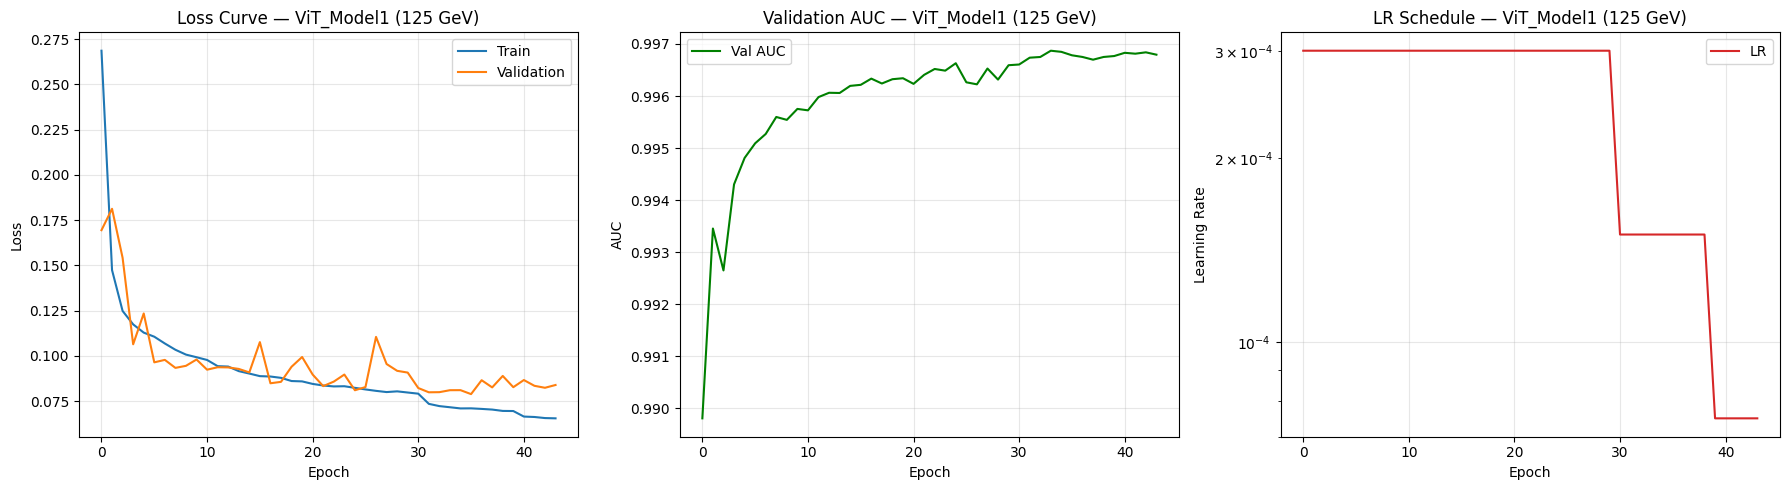

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses,   label="Validation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve — ViT_Model1 (125 GeV)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(val_aucs, color="green", label="Val AUC")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("AUC")
axes[1].set_title("Validation AUC — ViT_Model1 (125 GeV)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(lr_history, color="tab:red", label="LR")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate")
axes[2].set_title("LR Schedule — ViT_Model1 (125 GeV)")
axes[2].set_yscale("log"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_PATH / "training_curves_ViT_model1_125GeV.png", dpi=150)
plt.show()

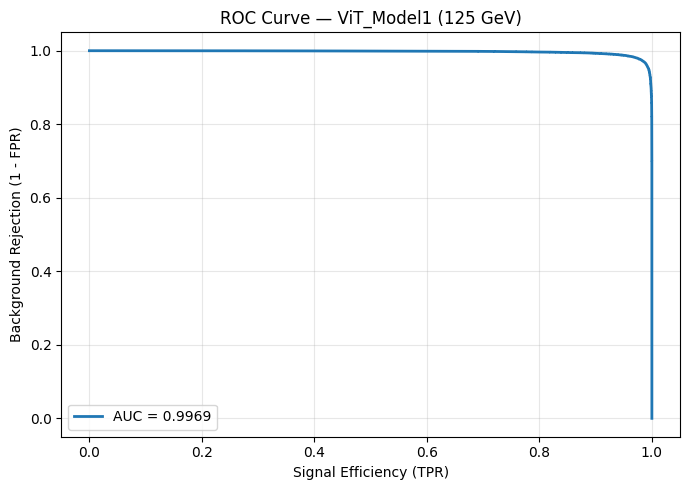

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(tpr, 1.0 - fpr, lw=2, label=f"AUC = {roc_auc:.4f}")
ax.set_xlabel("Signal Efficiency (TPR)")
ax.set_ylabel("Background Rejection (1 - FPR)")
ax.set_title("ROC Curve — ViT_Model1 (125 GeV)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_PATH / "roc_ViT_model1_125GeV.png", dpi=150)
plt.show()

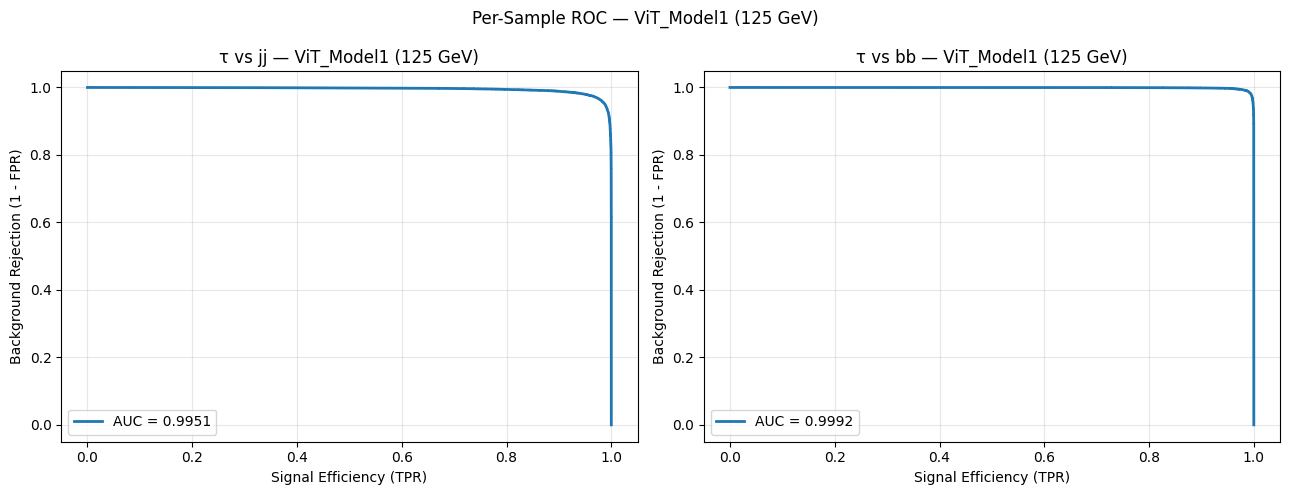

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (bkg_name, bkg_sid) in zip(axes, [("jj", 1), ("bb", 2)]):
    mask = (sid_val == 0) | (sid_val == bkg_sid)
    f_b, t_b, _ = roc_curve(y_true[mask], y_score[mask])
    ax.plot(t_b, 1.0 - f_b, lw=2, label=f"AUC = {auc(f_b, t_b):.4f}")
    ax.set_xlabel("Signal Efficiency (TPR)")
    ax.set_ylabel("Background Rejection (1 - FPR)")
    ax.set_title(f"τ vs {bkg_name} — ViT_Model1 (125 GeV)")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Per-Sample ROC — ViT_Model1 (125 GeV)", fontsize=12)
plt.tight_layout()
plt.savefig(RESULT_PATH / "roc_persample_ViT_model1_125GeV.png", dpi=150)
plt.show()

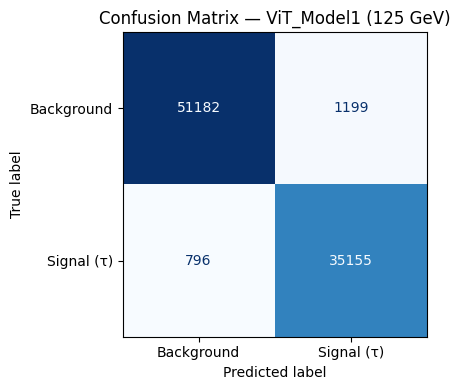

In [ ]:
cm   = confusion_matrix(y_true, preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Background", "Signal (τ)"]).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — ViT_Model1 (125 GeV)")
plt.tight_layout()
plt.savefig(RESULT_PATH / "confusion_matrix_ViT_model1_125GeV.png", dpi=150)
plt.show()

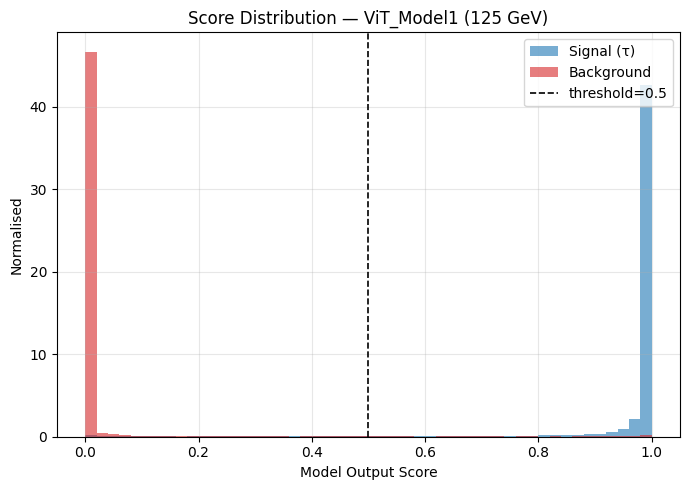

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(y_score[y_true == 1], bins=50, range=(0,1), density=True,
        alpha=0.6, color="tab:blue", label="Signal (τ)")
ax.hist(y_score[y_true == 0], bins=50, range=(0,1), density=True,
        alpha=0.6, color="tab:red",  label="Background")
ax.axvline(0.5, color="black", ls="--", lw=1.2, label="threshold=0.5")
ax.set_xlabel("Model Output Score")
ax.set_ylabel("Normalised")
ax.set_title("Score Distribution — ViT_Model1 (125 GeV)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_PATH / "score_dist_ViT_model1_125GeV.png", dpi=150)
plt.show()